# PROBLEM

<img src="Screenshot 2026-05-30 at 3.03.18 PM.png">

<img src="Screenshot 2026-05-30 at 2.45.01 PM.png">

<img src="Screenshot 2026-05-30 at 2.54.36 PM.png">
<img src="Screenshot 2026-05-30 at 2.57.06 PM.png">


<img src="Screenshot 2026-05-30 at 3.04.18 PM.png">

## Round 1 - To learn about Optuna (Optuna High-Level Overview)
### The Objective Function Pattern
(Dont run these two codes,its just for concepts)

In [1]:
"""
def objective(trial):
 # 1. Define search space (suggest hyperparameters)
 hidden_layers = trial.suggest_int('n_hidden_layers', 1, 5)
 neurons = trial.suggest_int('neurons_per_layer', 8, 128, step=8)

 # 2. Create model with these hyperparameters
 model = MyNeuralNetwork(input_dim, output_dim, hidden_layers,
neurons)

 # 3. Define loss function and optimizer
 criterion = nn.CrossEntropyLoss()
 optimizer = optim.SGD(model.parameters(), lr=learning_rate)

 # 4. Training loop
 for epoch in range(epochs):
    train_one_epoch()

 # 5. Evaluate and return accuracy
 accuracy = evaluate()
 return accuracy
 
"""

"\ndef objective(trial):\n # 1. Define search space (suggest hyperparameters)\n hidden_layers = trial.suggest_int('n_hidden_layers', 1, 5)\n neurons = trial.suggest_int('neurons_per_layer', 8, 128, step=8)\n\n # 2. Create model with these hyperparameters\n model = MyNeuralNetwork(input_dim, output_dim, hidden_layers,\nneurons)\n\n # 3. Define loss function and optimizer\n criterion = nn.CrossEntropyLoss()\n optimizer = optim.SGD(model.parameters(), lr=learning_rate)\n\n # 4. Training loop\n for epoch in range(epochs):\n    train_one_epoch()\n\n # 5. Evaluate and return accuracy\n accuracy = evaluate()\n return accuracy\n \n"

## Study Object Pattern

In [2]:
"""

# Create a study
study = optuna.create_study(direction='maximize') # maximize accuracy
# Run optimization
study.optimize(objective, n_trials=10)
# Get best results
best_accuracy = study.best_value
best_params = study.best_params

"""

"\n\n# Create a study\nstudy = optuna.create_study(direction='maximize') # maximize accuracy\n# Run optimization\nstudy.optimize(objective, n_trials=10)\n# Get best results\nbest_accuracy = study.best_value\nbest_params = study.best_params\n\n"

## SAME AS BEFORE


<img src ="./Screenshot 2026-05-30 at 12.47.35 PM.png">

<img src="Screenshot 2026-05-30 at 1.08.08 PM.png">

## Same as before

<img src="download.png">

<img src="a.png">

## for windows

In [3]:
import torch

#Check if GPU is available ,otherwise use CPU
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device:{device}")

using device:cpu


## for mac


In [4]:
import torch

device=torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device:{device}")

Using device:mps


<img src="b.png">

<img src= "c.png">

<img src= "d.png">

## 5. Detailed Code with Explanations

### 5.1 Import Dependencies and SetSeed (Reproducibility)

In [5]:
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# set seed for reproducibility
torch.manual_seed(42)

#### **Explanation**: Setting a seed ensures that every time you run the code, you get the same random numbers (same weight initialization, same data splits). This makes your results reproducible.

### 5.2 Load and Explore the Data

In [7]:
df=pd.read_csv("./fashion-mnist_train.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df.shape

(60000, 785)

### Two ways to separate X(features) and y(labels)
- using numpy
- using pandas

In [9]:
"""
# using numpy

## first column = label,next 784 column = pixel values
X=df.iloc[:,1:].values # features (784 columns)
y=df.iloc[:,0].values # labels (0 to 9)
print(X[:4])
print(y[:4])

"""

'\n# using numpy\n\n## first column = label,next 784 column = pixel values\nX=df.iloc[:,1:].values # features (784 columns)\ny=df.iloc[:,0].values # labels (0 to 9)\nprint(X[:4])\nprint(y[:4])\n\n'

In [10]:
# using pandas
X=df.drop(["label"],axis="columns").values
y=df["label"].values
print(X[:4])
print(y[:4])

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[2 9 6 0]


### Optional(for visualizing output)

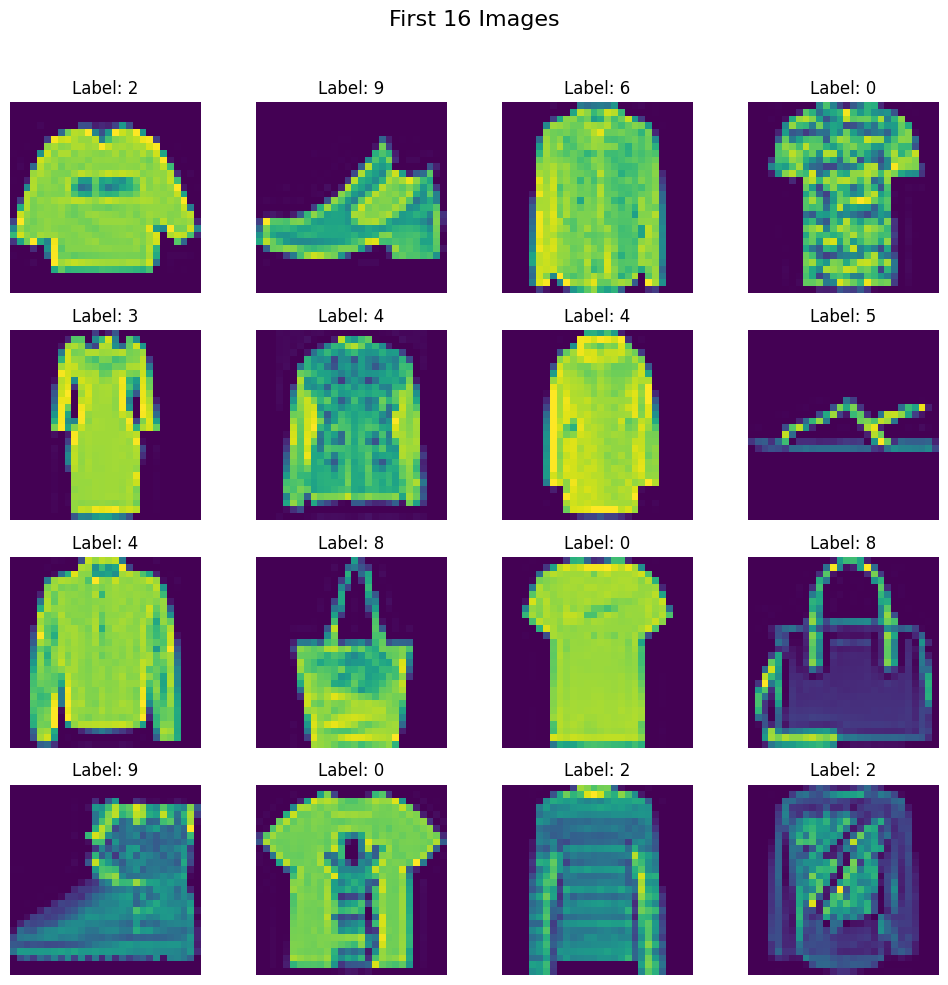

In [11]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

<img src="e.png">

### 5.3 Train-Test Split and Scaling

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#Scale pixel value from 0-255 to 0-1 (helps training stability)
X_train=X_train/255.0
X_test=X_test/255.0

print(X_train[:4])

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [13]:
"""
## or Directly use MinMax Scaler ,samething as above approach (/255)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  

print(X_train[:4])
"""

'\n## or Directly use MinMax Scaler ,samething as above approach (/255)\nfrom sklearn.preprocessing import MinMaxScaler\n\nscaler = MinMaxScaler()\nX_train = scaler.fit_transform(X_train)\nX_test = scaler.transform(X_test)  \n\nprint(X_train[:4])\n'

**Why scaling?**  Neural networks train more stably when input values are between 0 and 1 (or -1 and 1). Large values (0-255) can cause exploding gradients.

### 5.4 Custom Dataset Class

<img src="f.png">

In [14]:
class CustomDataset(Dataset):
    def __init__(self,features,labels):
        # Convert to Pytorch tensors with correct data types 
        self.features=torch.tensor(features,dtype=torch.float32)
        self.labels=torch.tensor(labels,dtype=torch.long)
    
    def __len__(self):
        # Return total number of samples
        return len(self.features)

    def __getitem__(self,index):
        # Return the sample (features, label) at given index
        # Apply transformations here if needed
        X=self.features[index]
        y=self.labels[index]
        return X,y

In [15]:
## creating dataset objects

# train dataset object
train_dataset=CustomDataset(features=X_train,labels=y_train)
#test dataset object
test_dataset=CustomDataset(features=X_test,labels=y_test)

print(len(train_dataset)) #Output: 4800 (if 6000 total,80% train)
print(train_dataset[0]) #Output : (tensor of 784 pixels ,tensor(7))

48000
(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2275,
        0.5333, 0.0000, 0.0000, 0

### 5.5 Create DataLoaders (train and test dataloader)

<img src="g.png">

<img src="h.png">

Setting shuffle=False during testing is a standard practice in machine learning because shuffling test data does not improve model evaluation and can complicate debugging.
While shuffling is critical during training to prevent the model from learning the order of data or getting stuck in local minima, it is typically disabled during testing for the following reasons:

* No Impact on Performance: Shuffling only affects the order of evaluation, not the final accuracy or loss. Since the model's weights are frozen during testing (inference), the order of samples does not change the mathematical outcome.
* Consistency and Reproducibility: Disabling shuffling ensures that predictions are always in the same order. This makes it easier to compare specific inputs with their corresponding outputs when calculating metrics like confusion matrices or manual error analysis. [2, 7] 
* Debugging: If you encounter an error or an outlier in your test results, having a fixed order allows you to pinpoint exactly which sample caused the issue. 



# Improvements here (hyperparameter Tuning Using Optuna)

<img src="Screenshot 2026-05-30 at 2.54.36 PM.png">
<img src="Screenshot 2026-05-30 at 2.57.06 PM.png">

#### Round 1 - tune/find out number of hidden layers and no of neurons per layer

### Before that you need to create a Dynamic Neural Network Class for running those combinations

This is the most important part. The network architecture must change based on
hyperparameters.

## Example to visualize first then code 
<img src="Screenshot 2026-05-30 at 6.48.40 PM.png">

<img src="Screenshot 2026-05-30 at 7.15.59 PM.png">

In [16]:



class MyNeuralNetwork(nn.Module):
    def __init__(self,input_dim,output_dim,num_hidden_layers,neurons_per_layer,dropout_rate):
        super().__init__()

        #Create a list to store all layers dynamically
        layers=[]

        #Input layer to first hidden layer
        current_input=input_dim

        #Loop to create each hidden layer of same size of neurons (neurons_per_layer)
        for i in range(num_hidden_layers):
            layers.append(nn.Linear(current_input,neurons_per_layer)) # for linear layer :input ->current_input ,output -> neurons_per_layer

            #Add Batch Normalization
            layers.append(nn.BatchNorm1d(neurons_per_layer))

            # Add Activation Function
            layers.append(nn.ReLU())

            #Add Dropout
            layers.append(nn.Dropout(dropout_rate))

            #Update input dimension for next layer
            current_input=neurons_per_layer
        
        
        #Output Layer
        layers.append(nn.Linear(neurons_per_layer,output_dim))

        #Create model (Sequential)
        self.model=nn.Sequential(*layers)
    
    def forward(self,x):
        return self.model(x)

## FOR ROUND2 - FULL OBJECTIVE FUNCTION (ALL 8 PARAMETERS)


### Objective function pattern

In [17]:



def objective(trial):
    """ 1. Define search space (suggest hyperparameters):next hyperparameters from search space """

    # ========== STEP 1: SUGGEST HYPERPARAMETERS ==========
    # 1. Suggest number of hidden layers (1 to 5)
    num_hidden_layers=trial.suggest_int("num_hidden_layers",1,5) # minm=1 hidden layer  maxm =5 hidden layers by bayesian search
    # 2. Suggest neurons per layer (8 to 128, step 8)
    neurons_per_layer=trial.suggest_int("neurons_per_layer",8,128,step=8) # minm =8 ,maxm=128 with step =8 i.e 8,16,24,...128
    # 3. Suggest Epochs (10 to 50, step 10)
    epochs=trial.suggest_int("epochs",10,50,step=10)
    # 4. suggest Learning Rate (log scale from 1e-5 to 1e-1)
    learning_rate=trial.suggest_float("learning_rate",1e-5,1e-1,log=True)
    # 5. suggest Dropout Rate (0.1 to 0.5)
    dropout_rate=trial.suggest_float("dropout_rate",0.1,0.5,step=0.1)
    # 6. suggest Batch Size (categorical choices)
    batch_size=trial.suggest_categorical("batch_size",[16,32,64,128])
    # 7. suggest  Optimizer Name (categorical)
    optimizer_name=trial.suggest_categorical("optimizer",["Adam","SGD","RMSprop"])

    weight_decay=trial.suggest_float("weight_decay",1e-5,1e-3,log=True)

    ##  STEP 2: CREATE DATA LOADERS WITH TUNED/Suggested BATCH SIZE 
    train_loader=DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=True  #changes here for gpu
    )

    test_loader=DataLoader(
        dataset=test_dataset,
        batch_size=batch_size,
        shuffle=False, # very important to set this false
        pin_memory=True #changes here for gpu
    )

    #  STEP 3. Initialize/Create model with these hyperparameters
    input_dim=784 #28*28 images flattened
    output_dim=10 #10 classes

    # Fixed hyperparameters for Round 1
    dropout_rate=0.3
    weight_decay=1e-4

    model=MyNeuralNetwork(input_dim=input_dim,output_dim=output_dim,num_hidden_layers=num_hidden_layers,neurons_per_layer=neurons_per_layer,dropout_rate=dropout_rate)
    model.to(device)

    

    # STEP 4. Define/select loss function
    criterion=nn.CrossEntropyLoss()
    optimizer=optim.SGD(model.parameters(),lr=learning_rate,weight_decay=weight_decay)

    # ========== STEP 5: OPTIMIZER (conditional on optimizer_name)
    if optimizer_name == "Adam":
        optimizer=optim.Adam(model.parameters(),lr=learning_rate,weight_decay=weight_decay)
    elif optimizer_name=="SGD":
        optimizer=optim.SGD(model.parameters(),lr=learning_rate,weight_decay=weight_decay)
    else:
        optimizer=optim.RMSprop(model.parameters(),lr=learning_rate,weight_decay=weight_decay)



    # ========== STEP 6: TRAINING LOOP ==========
    
    epochs=100
    num_batches=len(train_loader) # = 150

    for epoch in range(epochs):
        model.train()
        total_epoch_loss=0

        for batch_features,batch_labels in train_loader:
            #Changes here - move data to gpu
            batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
            #changes end
            
            # 1.forward pass : get predictions
            outputs=model(batch_features)

            #2.Calculate loss
            loss=criterion(outputs,batch_labels)

            #3. Clear previous gradients
            optimizer.zero_grad()

            #4.Backward pass (compute gradients)
            loss.backward()

            #5.Update weights
            optimizer.step()


            
    # ========== STEP 7: EVALUATION ==========
    # 5. Evaluate and return accuracy
    # set model to evaluation mode
    model.eval()

    total=0
    correct=0

    #Disable gradient calculation (saves memory and speed)
    with torch.no_grad():
        for batch_features,batch_labels in test_loader:
            
            #Changes here - move data to gpu
            batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
            #changes end

            #Forward pass
            outputs=model(batch_features)

            #Get predicted class (index with highest probability)
            #outputs shape:(batch_size,10)
            #torch.max returns (values,indices) along dimension 1
            _, predicted = torch.max(outputs,dim=1)

            #Update totals
            total=total+batch_labels.shape[0] # add batch size (32)

            correct=correct+(predicted == batch_labels).sum().item()


    accuracy=correct/total
    return accuracy

## Study Object Pattern

### to install Optuna
!pip install optuna

In [18]:
import optuna

#Create a study
study=optuna.create_study(direction="maximize") #maximize accuracy

#Run optimization
study.optimize(objective,n_trials=10)

/Users/kristalshrestha/Documents/Code/pytorch_practice/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-06-01 18:58:02,289] A new study created in memory with name: no-name-32b82a81-97fd-4d27-b285-c7774d72bab0
/Users/kristalshrestha/Documents/Code/pytorch_practice/venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
[W 2026-06-01 19:01:18,616] Trial 0 failed with parameters: {'num_hidden_layers': 5, 'neurons_per_layer': 8, 'epochs': 40, 'learning_rate': 0.00279374619237876, 'dropout_rate': 0.4, 'batch_size': 16, 'optimizer': 'RMSprop', 'weight_decay': 0.00011458963891128646} because of the following error: KeyboardInterrupt().
Traceba

KeyboardInterrupt: 

In [20]:
#get best results
best_accuracy=study.best_value
best_params=study.best_params

In [21]:
print(best_accuracy)
print(best_params)

0.893
{'num_hidden_layers': 2, 'neurons_per_layer': 96}


# ROUND 1 ENDS # ROUND 2 in next ipynb

# Improvements ends(hyperparameter Tuning)

### 5.6 Define Neural Network Class

<img src="i.png">

## Improvements Here
<img src="Screenshot 2026-05-30 at 1.08.08 PM.png">
<img src="Screenshot 2026-05-30 at 1.09.34 PM.png">

<img src="Screenshot 2026-05-30 at 1.56.43 PM.png">
<img src="Screenshot 2026-05-30 at 1.59.18 PM.png">

<img src="Screenshot 2026-05-30 at 2.04.49 PM.png">
<img src="Screenshot 2026-05-30 at 2.06.30 PM.png">

In [15]:
class MyNeuralNet(nn.Module):

    def __init__(self,num_features):

        super().__init__()
        self.network=nn.Sequential(
            nn.Linear(num_features,128), # input ->hidden1
            nn.BatchNorm1d(128),         # # 128 = number of neurons in output from first linear layer
            nn.ReLU(),                  #activation
            nn.Dropout(p=0.3),          ## 30% dropout
            nn.Linear(128,64),          # hidden1 -> hidden2
            nn.BatchNorm1d(64),         ## 64 = neurons in second linear layer
            nn.ReLU(),                  #activation
            nn.Dropout(p=0.3),           ## 30% dropout       
            nn.Linear(64,10),           #hidden2->output

            # No softmax here  - CrossEntropyLoss applies it internally
        )
    
    def forward(self,x):  # x.features
        out=self.network(x)
        return out

#### Output (conceptual):
During training, each forward pass uses a slightly different “thinned” network. During
evaluation, dropout is automatically disabled – no output change needed.

<img src="j.png">

In [16]:
# Instantiate model
input_size=X_train.shape[1] # = 784
model=MyNeuralNet(num_features=input_size)

# Move the model to the GPU (or CPU if GPU not available)
model=model.to(device)

### 5.7  Loss Function and Optimizer


<img src="k.png">

In [17]:
# loss function
criterion=nn.CrossEntropyLoss() # for multi-class classification

#optimizer
learning_rate=0.01
optimizer=optim.SGD(model.parameters(),lr=learning_rate,weight_decay=1e-4) ## weight_decay = 0.0001 (λ value) for regularization

### Improvements end here for regularization,dropout and batch normalization

### 5.8 Training Loop

<img src="m.png">

<img src="l.png">

In [18]:
## to find no of batches in training

len(train_loader) # 150 batches

1500

In [ ]:
model.train()
epochs=100
num_batches=len(train_loader) # = 150

for epoch in range(epochs):

    total_epoch_loss=0

    for batch_features,batch_labels in train_loader:
        #Changes here - move data to gpu
        batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
        #changes end
        
        # 1.forward pass : get predictions
        outputs=model(batch_features)

        #2.Calculate loss
        loss=criterion(outputs,batch_labels)

        #3. Clear previous gradients
        optimizer.zero_grad()

        #4.Backward pass (compute gradients)
        loss.backward()

        #5.Update weights
        optimizer.step()


        total_epoch_loss=total_epoch_loss+loss.item()
    
    avg_loss=total_epoch_loss/num_batches
    print(f"Epoch {epoch+1}/{epochs},Loss:{avg_loss:.4f}")

/Users/kristalshrestha/Documents/Code/pytorch_practice/venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/100,Loss:0.8199
Epoch 2/100,Loss:0.5669
Epoch 3/100,Loss:0.5125
Epoch 4/100,Loss:0.4826
Epoch 5/100,Loss:0.4635
Epoch 6/100,Loss:0.4461
Epoch 7/100,Loss:0.4324
Epoch 8/100,Loss:0.4248
Epoch 9/100,Loss:0.4104
Epoch 10/100,Loss:0.4094
Epoch 11/100,Loss:0.3967
Epoch 12/100,Loss:0.3905
Epoch 13/100,Loss:0.3811
Epoch 14/100,Loss:0.3747
Epoch 15/100,Loss:0.3693
Epoch 16/100,Loss:0.3633
Epoch 17/100,Loss:0.3608
Epoch 18/100,Loss:0.3564
Epoch 19/100,Loss:0.3504
Epoch 20/100,Loss:0.3482
Epoch 21/100,Loss:0.3400
Epoch 22/100,Loss:0.3393
Epoch 23/100,Loss:0.3335
Epoch 24/100,Loss:0.3342
Epoch 25/100,Loss:0.3309
Epoch 26/100,Loss:0.3292
Epoch 27/100,Loss:0.3247
Epoch 28/100,Loss:0.3215
Epoch 29/100,Loss:0.3176
Epoch 30/100,Loss:0.3142
Epoch 31/100,Loss:0.3124
Epoch 32/100,Loss:0.3085
Epoch 33/100,Loss:0.3071
Epoch 34/100,Loss:0.3082
Epoch 35/100,Loss:0.3028
Epoch 36/100,Loss:0.3000
Epoch 37/100,Loss:0.2996
Epoch 38/100,Loss:0.2982
Epoch 39/100,Loss:0.2980
Epoch 40/100,Loss:0.2937
Epoch 41/

### 5.9 Evaluation Code (Accuracy Calculation)

<img src="n.png">

<img src="o.png">

<img src="p.png">

In [20]:
## to find no of batches in testing

len(test_loader)

375

In [21]:
# set model to evaluation mode
model.eval()

total=0
correct=0

#Disable gradient calculation (saves memory and speed)
with torch.no_grad():
    for batch_features,batch_labels in test_loader:
        
        #Changes here - move data to gpu
        batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
        #changes end

        #Forward pass
        outputs=model(batch_features)

        #Get predicted class (index with highest probability)
        #outputs shape:(batch_size,10)
        #torch.max returns (values,indices) along dimension 1
        _, predicted = torch.max(outputs,dim=1)

        #Update totals
        total=total+batch_labels.shape[0] # add batch size (32)

        correct=correct+(predicted == batch_labels).sum().item()


print(correct/total)

0.8919166666666667


### Now checking training accuracy

In [22]:
# set model to evaluation mode
model.eval()

total=0
correct=0

#Disable gradient calculation (saves memory and speed)
with torch.no_grad():
    for batch_features,batch_labels in train_loader:#test_loader -> train_loader for training accuracy
        
        #Changes here - move data to gpu
        batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
        #changes end

        #Forward pass
        outputs=model(batch_features)

        #Get predicted class (index with highest probability)
        #outputs shape:(batch_size,10)
        #torch.max returns (values,indices) along dimension 1
        _, predicted = torch.max(outputs,dim=1)

        #Update totals
        total=total+batch_labels.shape[0] # add batch size (32)

        correct=correct+(predicted == batch_labels).sum().item()


print(correct/total)

0.9559791666666667


#### model overfit can be seen from below as in training its 96% and testing its 88%.We will deal with this on next one.

## Added 
## Conclusion:
 The gap between testing and training accuracy reduced significantly (from ~10% to ~6%(95%-89%)).Overfitting is reduced. 
 The model now generalizes better to unseen data. Test accuracy remained almost the same (slight
drop from 88.7% to 88.3% is acceptable because we trade a tiny bit of training performance for
much better generalization).

# COMPLETE CODE (ALL TOGETHER)

In [ ]:
# 1. Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split

# 2. Set seed
torch.manual_seed(42)

device=torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device:{device}")

# 3. Load data
data = pd.read_csv('fmnist_small.csv')
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

# 4. Train-test split & scaling
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=42)
X_train = X_train / 255.0
X_test = X_test / 255.0

# 5. Custom Dataset
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.features)
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


# 6. DataLoaders
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 7. Neural Network
class MyNeuralNet(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.model = nn.Sequential(
                        nn.Linear(input_features, 128),
                        nn.ReLU(),
                        nn.Linear(128, 64),
                        nn.ReLU(),
                        nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.model(x)

# 8. Model, Loss, Optimizer
model = MyNeuralNet(784)
# Move the model to the GPU (or CPU if GPU not available)
model=model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 9. Training
epochs = 100
for epoch in range(epochs):
    total_loss = 0
    for features, labels in train_loader:
         #Changes here - move data to gpu
        features,labels=features.to(device),labels.to(device)
        #changes end
        outputs = model(features)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss:{total_loss/len(train_loader):.4f}")

# 10. Evaluation
model.eval()
correct = total = 0
with torch.no_grad():
    for features, labels in test_loader:
        #Changes here - move data to gpu
        features,labels=features.to(device),labels.to(device)
        #changes end
        outputs = model(features)
        _, predicted = torch.max(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Accuracy: {100 * correct / total:.2f}%")

<img src ="q.png">

<img src="r.png">

## Added

<img src="Screenshot 2026-05-30 at 2.20.33 PM.png">